### Noteboook for Comparing Decision Tree with enrtopy and gini

* Entropy and Gini are two different criteria used to measure the impurity of a dataset in decision tree algorithms.
* Entropy is a measure of the disorder or randomness in a dataset, while Gini is a measure of the impurity of a dataset.
* Both criteria are used to determine the best split for a decision tree, but they may yield different results depending on the dataset and the specific implementation of the decision tree algorithm.

In [29]:
import pandas as pd 
import zipfile

In [30]:
with zipfile.ZipFile('Dataset/adult.zip', 'r') as zip_ref:
    zip_ref.extractall('Dataset/')

In [31]:
df = pd.read_csv('Dataset/adult.data')
df.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [32]:
df.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32560 non-null  int64 
 1   workclass       32560 non-null  object
 2   fnlwgt          32560 non-null  int64 
 3   education       32560 non-null  object
 4   education-num   32560 non-null  int64 
 5   marital-status  32560 non-null  object
 6   occupation      32560 non-null  object
 7   relationship    32560 non-null  object
 8   race            32560 non-null  object
 9   sex             32560 non-null  object
 10  capital-gain    32560 non-null  int64 
 11  capital-loss    32560 non-null  int64 
 12  hours-per-week  32560 non-null  int64 
 13  native-country  32560 non-null  object
 14  income          32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [34]:
count = df["income"].value_counts()

income
<=50K    24719
>50K      7841
Name: count, dtype: int64


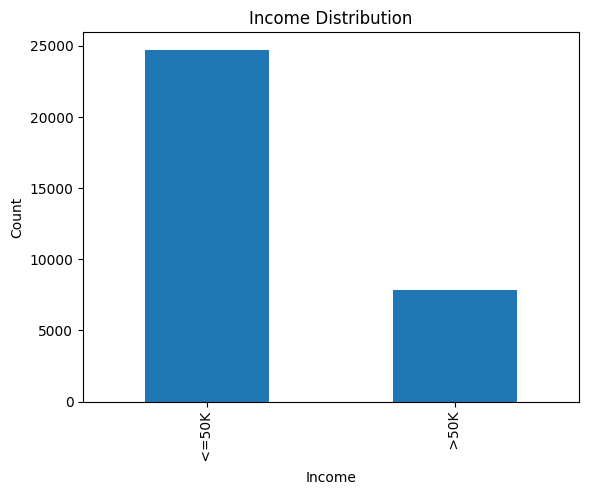

In [35]:
import matplotlib.pyplot as plt

count.plot(kind='bar')
plt.xlabel('Income')
plt.ylabel('Count')
plt.title('Income Distribution')
print(count)

In [36]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')


In [37]:
cate_df = df[categorical_cols]
non_cate_df = df.drop(columns=categorical_cols)
ohe_df = pd.get_dummies(cate_df, drop_first=True)


In [38]:
ohe_df.head()

,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,workclass_ Without-pay,education_ 11th,education_ 12th,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income_ >50K
0,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [39]:
new_df = pd.concat([non_cate_df, ohe_df], axis=1)
new_df.head(3)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income_ >50K
0,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,38,215646,9,0,0,40,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
2,53,234721,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False


In [40]:
y = new_df['income_ >50K']
X = new_df.drop(columns=['income_ >50K'])

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
X_train.shape

(26048, 100)

* Test for Entropy 

In [43]:
from sklearn.tree import DecisionTreeClassifier 

model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [44]:
print('Training Accuracy: ', model_entropy.score(X_train, y_train))
print('Testing Accuracy: ', model_entropy.score(X_test, y_test))
print('Depth: ', model_entropy.get_depth())

Training Accuracy:  0.9999616093366094
Testing Accuracy:  0.8178746928746928
Depth:  56


In [45]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model_entropy.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.88      0.88      0.88      4912
        True       0.63      0.63      0.63      1600

    accuracy                           0.82      6512
   macro avg       0.75      0.76      0.75      6512
weighted avg       0.82      0.82      0.82      6512



<Axes: >

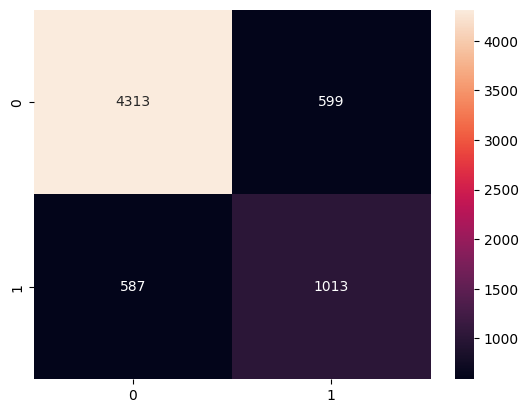

In [46]:
import seaborn as sns 

cnf_entropy = confusion_matrix(y_test, y_pred)
sns.heatmap(cnf_entropy, annot=True, fmt='d')

* Test for Gini

In [47]:
model_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
model_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [48]:
print("Training Accuracy: ", model_gini.score(X_train, y_train))
print("Testing Accuracy: ", model_gini.score(X_test, y_test))
print("Depth: ", model_gini.get_depth())

Training Accuracy:  0.9999616093366094
Testing Accuracy:  0.8125
Depth:  47


In [49]:
print(classification_report(y_test, model_gini.predict(X_test)))

              precision    recall  f1-score   support

       False       0.87      0.88      0.88      4912
        True       0.62      0.61      0.62      1600

    accuracy                           0.81      6512
   macro avg       0.75      0.74      0.75      6512
weighted avg       0.81      0.81      0.81      6512



<Axes: >

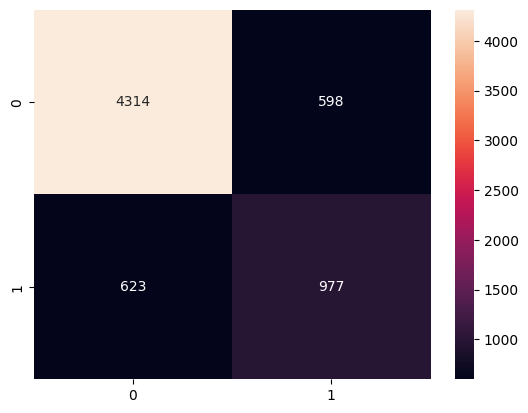

In [50]:
cnf_gini = confusion_matrix(y_test, model_gini.predict(X_test))
sns.heatmap(cnf_gini, annot=True, fmt='d')

#### Comparision

In [52]:


training_acc = {
    'Entropy': model_entropy.score(X_train, y_train),
    'Gini': model_gini.score(X_train, y_train)
}

testing_acc = {
    'Entropy': model_entropy.score(X_test, y_test),
    'Gini': model_gini.score(X_test, y_test)
}

precision = {
    'Entropy': cnf_entropy[1][1] / (cnf_entropy[0][1] + cnf_entropy[1][1]),
    'Gini': cnf_gini[1][1] / (cnf_gini[0][1] + cnf_gini[1][1])
}

recall = {
    'Entropy': cnf_entropy[1][1] / (cnf_entropy[1][0] + cnf_entropy[1][1]),
    'Gini': cnf_gini[1][1] / (cnf_gini[1][0] + cnf_gini[1][1])
}

f1_score = {
    'Entropy': cnf_entropy[1][1] / (cnf_entropy[0][1] + cnf_entropy[1][0] + cnf_entropy[1][1]),
    'Gini': cnf_gini[1][1] / (cnf_gini[0][1] + cnf_gini[1][0] + cnf_gini[1][1])
}

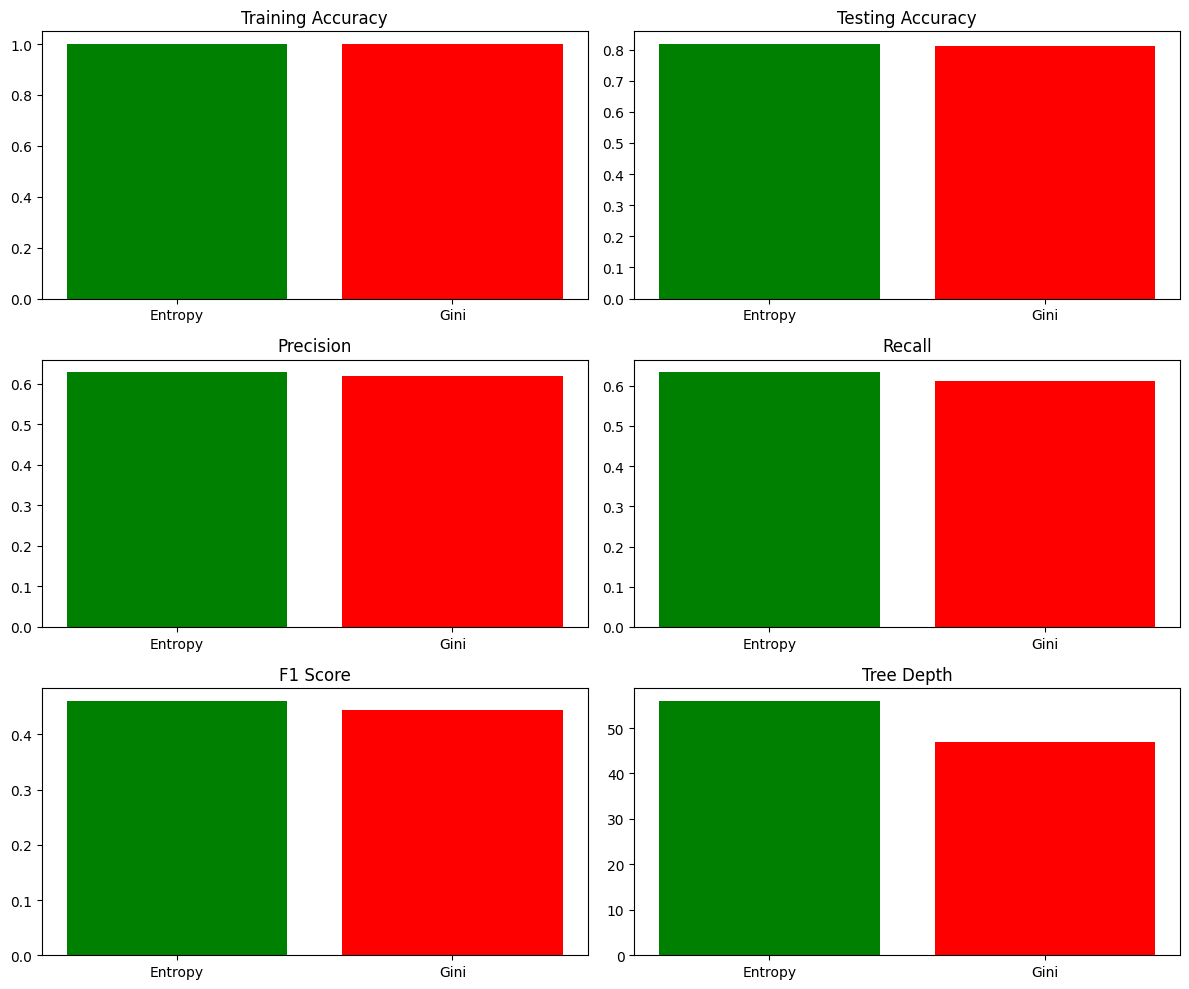

In [57]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

axs[0, 0].bar(training_acc.keys(), training_acc.values(), color=['green', 'red'])
axs[0, 0].set_title('Training Accuracy')

axs[0, 1].bar(testing_acc.keys(), testing_acc.values(), color=['green', 'red'])
axs[0, 1].set_title('Testing Accuracy')

axs[1, 0].bar(precision.keys(), precision.values(), color=['green', 'red'])
axs[1, 0].set_title('Precision')

axs[1, 1].bar(recall.keys(), recall.values(), color=['green', 'red'])
axs[1, 1].set_title('Recall')

axs[2, 0].bar(f1_score.keys(), f1_score.values(), color=['green', 'red'])
axs[2, 0].set_title('F1 Score')

axs[2, 1].bar(['Entropy', 'Gini'], [model_entropy.get_depth(), model_gini.get_depth()], color=['green', 'red'])
axs[2, 1].set_title('Tree Depth')

plt.tight_layout()
plt.show()